In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D

In [ ]:
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

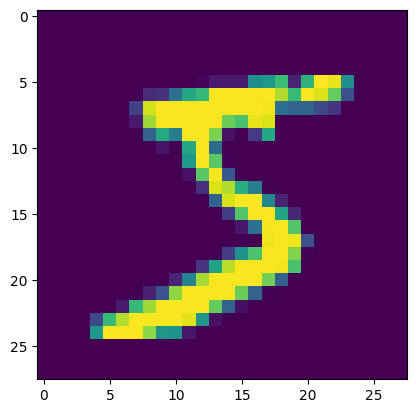

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0])

In [ ]:
x_train = x_train/255
x_test = x_test/255

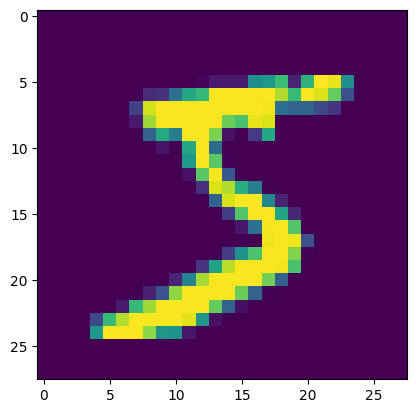

In [ ]:
plt.imshow(x_train[0])

In [ ]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,554 (236.54 KB)

 Trainable params: 60,554 (236.54 KB)

 Non-trainable params: 0 (0.00 B)

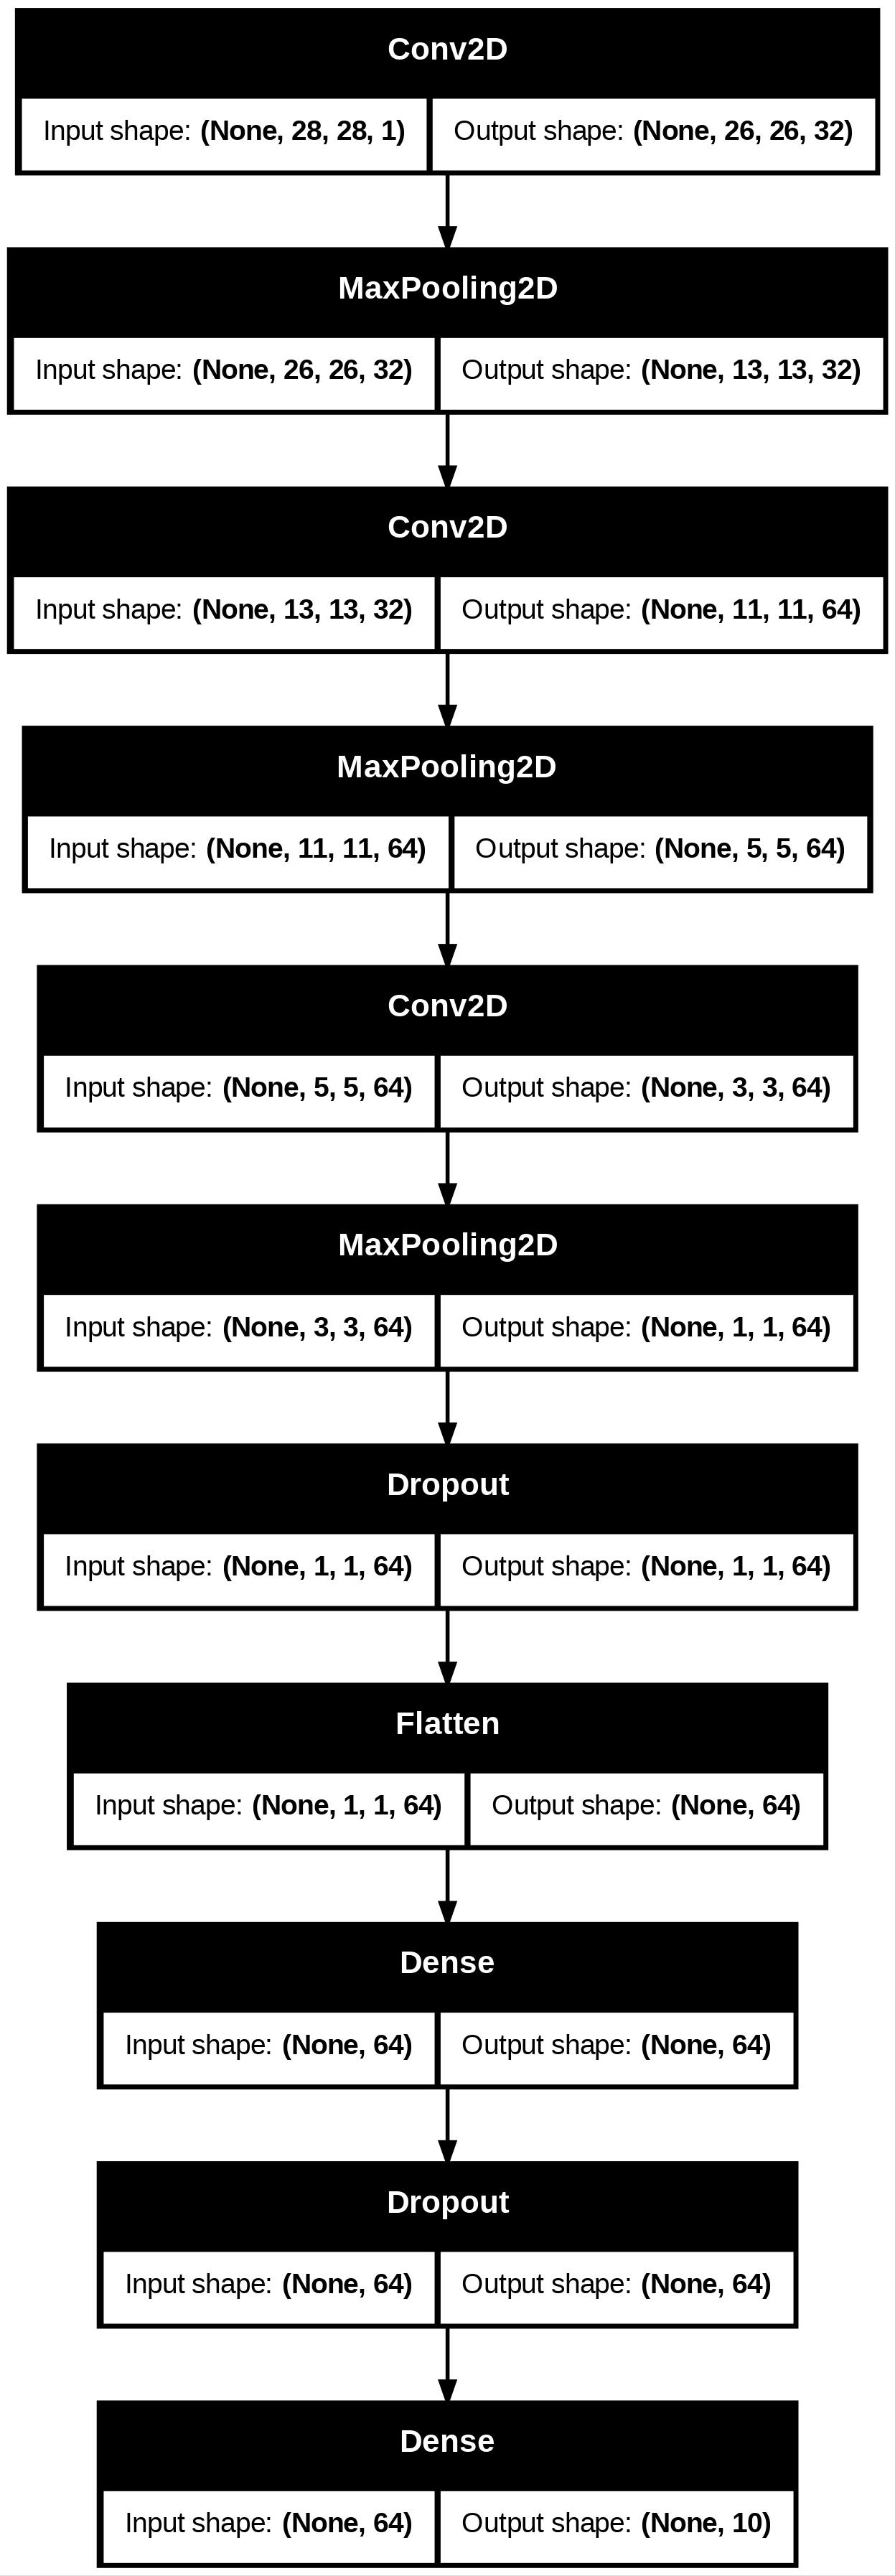

In [ ]:
from keras.src.utils import plot_model
plot_model(model,'model.jpg',show_shapes=True)

In [ ]:
model.fit(x_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.8262 - loss: 0.5476 - val_accuracy: 0.9670 - val_loss: 0.1118
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.9439 - loss: 0.1993 - val_accuracy: 0.9766 - val_loss: 0.0829
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 30ms/step - accuracy: 0.9583 - loss: 0.1515 - val_accuracy: 0.9793 - val_loss: 0.0744
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9654 - loss: 0.1258 - val_accuracy: 0.9833 - val_loss: 0.0616
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9705 - loss: 0.1049 - val_accuracy: 0.9854 - val_loss: 0.0560
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.9749 - loss: 0.0962 - val_accuracy: 0.9839 - val_loss: 0.0547
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 29ms/step - accuracy: 0.9770 - loss: 0.0819 - val_accuracy: 0.9808 - val_loss: 0.0746
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.9785 -

In [ ]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


In [ ]:
y_pred =y_pred.argmax(axis=1)

In [ ]:
y_pred

array([7, 2, 1, ..., 4, 5, 6])

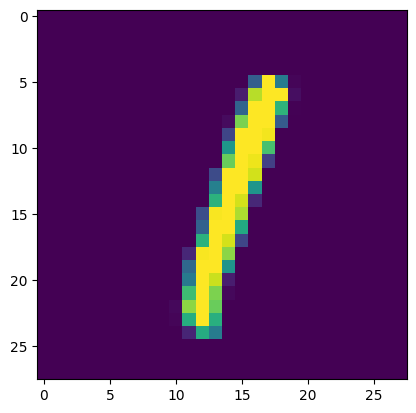

In [ ]:
plt.imshow(x_test[5])

In [ ]:
print(y_pred[5])

1


In [ ]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9836 - loss: 0.0630


[0.06299716234207153, 0.9836000204086304]

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)

In [ ]:
cm

array([[ 971,    0,    4,    1,    0,    0,    1,    1,    0,    2],
       [   1, 1126,    1,    3,    0,    1,    1,    2,    0,    0],
       [   1,    0, 1020,    4,    0,    0,    0,    7,    0,    0],
       [   0,    0,    1, 1006,    0,    2,    0,    1,    0,    0],
       [   0,    0,    0,    0,  962,    0,    3,    1,    0,   16],
       [   5,    0,    0,   14,    0,  866,    2,    1,    1,    3],
       [   7,    4,    3,    0,    3,    1,  938,    0,    1,    1],
       [   0,    2,   16,    4,    0,    0,    0, 1003,    1,    2],
       [   1,    0,    2,    3,    4,    1,    0,    0,  953,   10],
       [   1,    0,    0,    1,    3,    5,    0,    6,    2,  991]])

In [ ]:
from sklearn.metrics import classification_report
cr = classification_report(y_test,y_pred)


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9836

CIFAR DATASET

In [ ]:
from keras.datasets import cifar10

In [ ]:
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
print('CIFAR-10 training data shape:', x_train_cifar.shape)
print('CIFAR-10 test data shape:', x_test_cifar.shape)


CIFAR-10 training data shape: (50000, 32, 32, 3)
CIFAR-10 test data shape: (10000, 32, 32, 3)


In [ ]:
model_cifar = Sequential()
model_cifar.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model_cifar.add(MaxPooling2D((2, 2)))
model_cifar.add(Conv2D(64, (3, 3), activation='relu'))
model_cifar.add(MaxPooling2D((2, 2)))
model_cifar.add(Conv2D(64, (3, 3), activation='relu'))
model_cifar.add(Flatten())
model_cifar.add(Dense(64, activation='relu'))
model_cifar.add(Dropout(0.5))
model_cifar.add(Dense(10, activation='softmax')) # CIFAR-10 has 10 classes

model_cifar.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model_cifar.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the CIFAR-10 model
# Using 'y_train_cifar' and 'y_test_cifar' directly as they are already integers representing classes
history_cifar = model_cifar.fit(x_train_cifar, y_train_cifar, epochs=10, validation_split=0.2)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 56s 44ms/step - accuracy: 0.3514 - loss: 1.7587 - val_accuracy: 0.5179 - val_loss: 1.3591
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 77s 40ms/step - accuracy: 0.4915 - loss: 1.4150 - val_accuracy: 0.5773 - val_loss: 1.1987
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.5509 - loss: 1.2767 - val_accuracy: 0.6194 - val_loss: 1.0883
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.5877 - loss: 1.1773 - val_accuracy: 0.6295 - val_loss: 1.0439
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.6189 - loss: 1.0923 - val_accuracy: 0.6426 - val_loss: 1.0203
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.6439 - loss: 1.0261 - val_accuracy: 0.6700 - val_loss: 0.9406
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.6583 - loss: 0.9767 - val_accuracy: 0.6673 - val_loss: 0.9647
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 42ms/step - accuracy: 0.6788 -

In [ ]:
# Evaluate the CIFAR-10 model on test data
loss_cifar, accuracy_cifar = model_cifar.evaluate(x_test_cifar, y_test_cifar)
print(f'CIFAR-10 Test Loss: {loss_cifar:.4f}')
print(f'CIFAR-10 Test Accuracy: {accuracy_cifar:.4f}')


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6920 - loss: 0.9015
CIFAR-10 Test Loss: 0.9015
CIFAR-10 Test Accuracy: 0.6920


In [ ]:
y_pred_cifar = model_cifar.predict(x_test_cifar)
y_pred_cifar_classes = np.argmax(y_pred_cifar, axis=1)

# Display classification report and confusion matrix for CIFAR-10
from sklearn.metrics import classification_report, confusion_matrix

print('\nCIFAR-10 Classification Report:')
print(classification_report(y_test_cifar, y_pred_cifar_classes))

print('\nCIFAR-10 Confusion Matrix:')
cm_cifar = confusion_matrix(y_test_cifar, y_pred_cifar_classes)
print(cm_cifar)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

CIFAR-10 Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.78      0.72      1000
           1       0.80      0.86      0.83      1000
           2       0.57      0.59      0.58      1000
           3       0.56      0.40      0.46      1000
           4       0.55      0.73      0.63      1000
           5       0.66      0.50      0.57      1000
           6       0.68      0.84      0.75      1000
           7       0.80      0.69      0.74      1000
           8       0.83      0.78      0.81      1000
           9       0.81      0.76      0.79      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000


CIFAR-10 Confusion Matrix:
[[775  26  62   5  22   2  13   6  56  33]
 [ 21 859   8   4   8   3  16   1  15  65]
 [ 84   8 588  33 135  44  74  15  11   8]
 [ 26  12

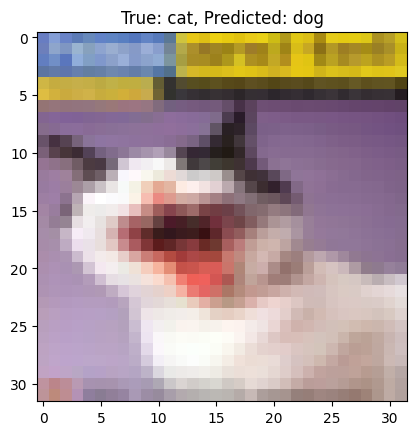

In [ ]:
# Example of displaying a prediction from CIFAR-10 test set
import random

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

idx = random.randint(0, len(x_test_cifar) - 1)
plt.imshow(x_test_cifar[idx])
plt.title(f"True: {class_names[y_test_cifar[idx][0]]}, Predicted: {class_names[y_pred_cifar_classes[idx]]}")
plt.show()


Industry Detection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
image_size=[224,224]
train_path='/content/drive/MyDrive/casting_data/train'
test_path='/content/drive/MyDrive/casting_data/test'

In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation and Preprocessing for Training Data
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

# Preprocessing for Test Data (only rescaling)
test_datagen = ImageDataGenerator(rescale = 1./255)

# Create Training Set
training_set = train_datagen.flow_from_directory(
    train_path,
    target_size = image_size,
    batch_size = 32,
    class_mode = 'binary' # Assuming binary classification for casting data
)

# Create Test Set
test_set = test_datagen.flow_from_directory(
    test_path,
    target_size = image_size,
    batch_size = 32,
    class_mode = 'binary' # Assuming binary classification for casting data
)

print("Class Indices for Training Set:", training_set.class_indices)
print("Class Indices for Test Set:", test_set.class_indices)

Found 6744 images belonging to 2 classes.
Found 715 images belonging to 2 classes.
Class Indices for Training Set: {'def_front': 0, 'ok_front': 1}
Class Indices for Test Set: {'def_front': 0, 'ok_front': 1}


In [ ]:
# Define the CNN model for casting data
model_casting = Sequential()

# First convolutional block
model_casting.add(Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)))
model_casting.add(MaxPooling2D((2, 2)))

# Second convolutional block
model_casting.add(Conv2D(64, (3, 3), activation='relu'))
model_casting.add(MaxPooling2D((2, 2)))

# Third convolutional block
model_casting.add(Conv2D(128, (3, 3), activation='relu')) # Increased filters for larger images
model_casting.add(MaxPooling2D((2, 2)))

# Flatten the output for the fully connected layers
model_casting.add(Flatten())

# Fully connected layers
model_casting.add(Dense(128, activation='relu'))
model_casting.add(Dropout(0.5)) # Dropout for regularization

# Output layer for binary classification (2 classes: def_front, ok_front)
model_casting.add(Dense(1, activation='sigmoid'))

# Compile the model
model_casting.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

# Display model summary
model_casting.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_casting = model_casting.fit(training_set,
                                    validation_data=test_set,
                                    epochs=5)

Epoch 1/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3863s 18s/step - accuracy: 0.5989 - loss: 0.6656 - val_accuracy: 0.6685 - val_loss: 0.5906
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 969s 5s/step - accuracy: 0.8020 - loss: 0.4272 - val_accuracy: 0.6182 - val_loss: 0.6899
Epoch 3/5
118/211 ━━━━━━━━━━━━━━━━━━━━ 6:33 4s/step - accuracy: 0.8292 - loss: 0.3726

In [ ]:


# Evaluate the model on the test set
loss_casting, accuracy_casting = model_casting.evaluate(test_set)
print(f'Casting Data Test Loss: {loss_casting:.4f}')
print(f'Casting Data Test Accuracy: {accuracy_casting:.4f}')

In [ ]:
# Make predictions on the test set
y_pred_casting = model_casting.predict(test_set)

# Since it's binary classification with sigmoid output, values > 0.5 are class 1 (ok_front)
y_pred_casting_classes = (y_pred_casting > 0.5).astype(int)

# Get true labels from the test generator
y_true_casting = test_set.classes

# Display classification report and confusion matrix for Casting Data
from sklearn.metrics import classification_report, confusion_matrix

print('\nCasting Data Classification Report:')
print(classification_report(y_true_casting, y_pred_casting_classes))

print('\nCasting Data Confusion Matrix:')
cm_casting = confusion_matrix(y_true_casting, y_pred_casting_classes)
print(cm_casting)